In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cufflinks as cf
from IPython.display import display, HTML

# Part 1: Problem framing & EDA

## Required Text

- Dataset description and source
    - UCI's Bank-Marketing Dataset 2011
    - The goal of the dataset is to analyze which types of customers are more likely to subscribe to a term deposit
- Problem type
    - Classification
    - Clustering
- Target variable
    - y (indicates if customer subscribed(yes) or not(no))
- Key input features
    - duration
    - balance
- One-line success criterion

## EDA

In [6]:
df = pd.read_csv(r'D:\Downloads\bank+marketing\bank\bank.csv', sep=';')

In [63]:
df.sample(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3918,45,technician,married,secondary,no,49,no,no,cellular,29,jul,65,2,-1,0,unknown,no
2051,31,admin.,single,secondary,no,747,yes,no,unknown,26,may,543,2,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
2792,32,blue-collar,married,secondary,no,478,yes,no,unknown,3,jun,200,1,-1,0,unknown,no
4271,47,blue-collar,divorced,primary,no,1279,yes,no,cellular,6,feb,479,2,-1,0,unknown,no
2335,33,admin.,single,tertiary,no,490,yes,no,cellular,7,may,31,1,363,2,failure,no
1000,34,technician,married,secondary,no,209,yes,yes,cellular,8,apr,375,2,-1,0,unknown,no
955,39,management,single,tertiary,no,816,yes,no,cellular,27,aug,37,3,-1,0,unknown,no
453,32,blue-collar,married,secondary,no,34,yes,no,cellular,5,may,321,2,-1,0,unknown,no
2730,52,self-employed,married,secondary,no,9,no,yes,unknown,6,jun,44,1,-1,0,unknown,no


In [14]:
df.shape

(4521, 17)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [17]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [19]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


<Axes: xlabel='y', ylabel='count'>

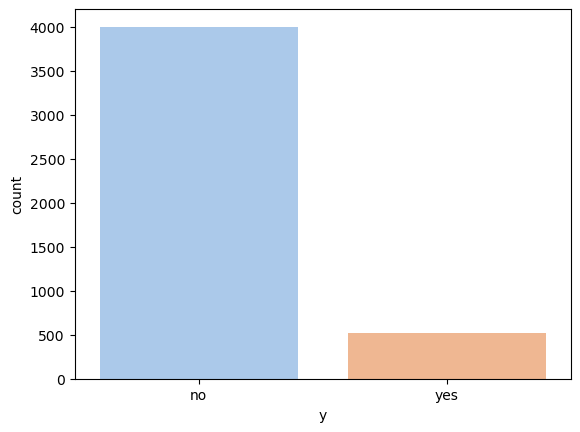

In [26]:
# Target Distribution
sns.countplot(data=df, x='y', hue='y', palette='pastel')

Text(0.5, 1.0, 'Zoomed')

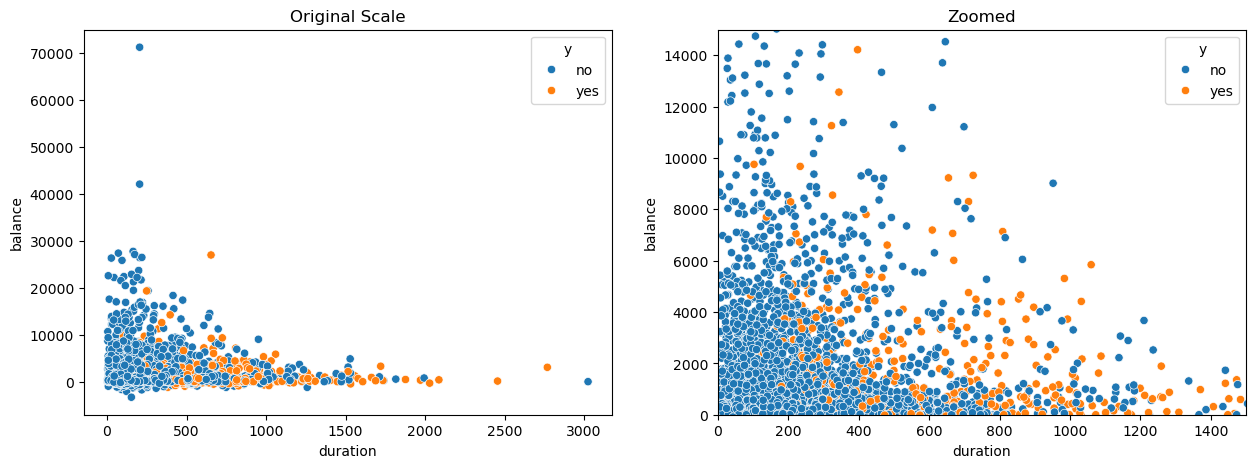

In [49]:
# Feature relationship
fig, ax = plt.subplots(ncols=2, figsize=(15,5))

sns.scatterplot(data=df, x='duration', y='balance', hue='y', ax=ax[0])
ax[0].set_title("Original Scale")

sns.scatterplot(data=df, x='duration', y='balance', hue='y', ax=ax[1])
ax[1].set_xlim(0, 1500)
ax[1].set_ylim(0, 15000)
ax[1].set_title("Zoomed")

Text(0.5, 1.0, 'Average Balance')

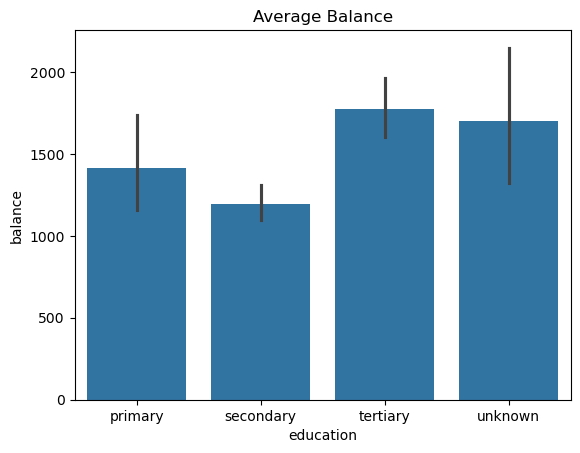

In [68]:
sns.barplot(x='education', y='balance', data=df, estimator=np.mean, color='')
plt.title("Average Balance")

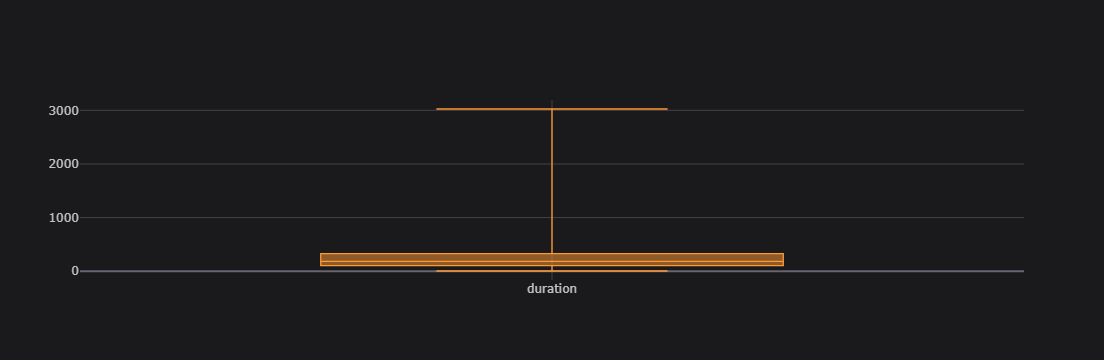

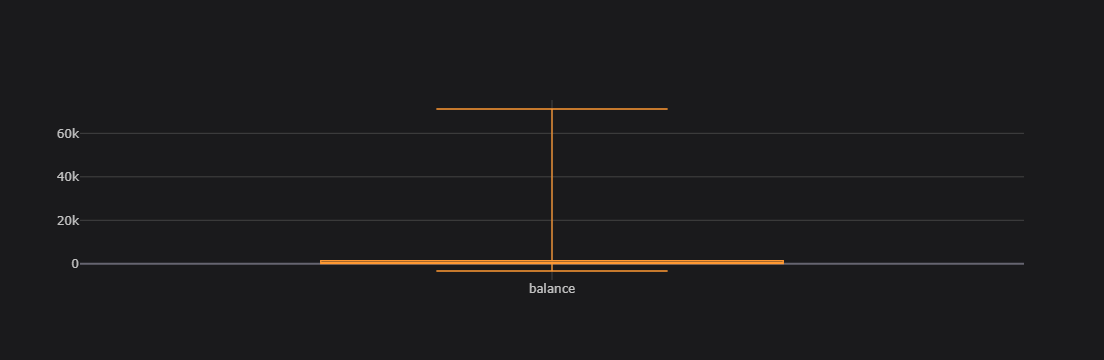

In [56]:
# Outlier Check
df['duration'].iplot(kind='box')
df['balance'].iplot(kind='box')

## Observations

- The target distribution is imbalance. Roughly 10:1 (No:Yes)
- No single strong feature relation found
- Large Outliers present